In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [10]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/q2_customers.csv")

# Display basic info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nFirst 5 rows:\n", df.head())

Shape: (500, 6)

Columns:
 Index(['age', 'annual_spend', 'visits_per_month', 'basket_size',
       'days_since_last_visit', 'num_categories_purchased'],
      dtype='str')

First 5 rows:
    age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  


In [11]:
X = df.copy()

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Why Scaling is Important before K-Means?

As a distance-driven method, K-Means uses Euclidean distance for grouping points. Differing feature scales (such as age compared to annual_spend) cause issues, where high-range variables—like spending in thousands versus visits_per_month in low single digits—take control. Unscaled data biases clusters toward bigger values. By applying StandardScaler, features get adjusted to mean 0 and SD of 1, ensuring balanced contributions for better, more interpretable results.

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [14]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

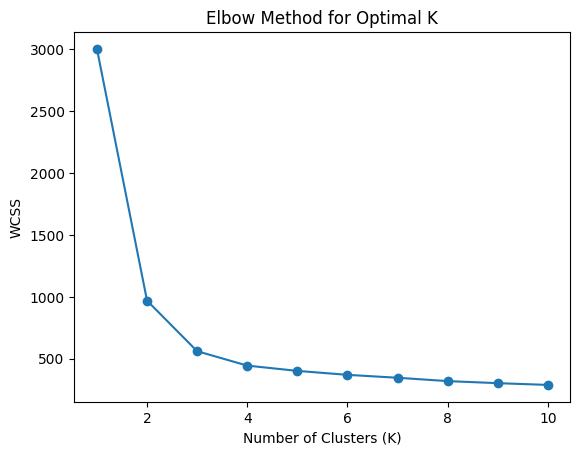

In [15]:
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

### Elbow Method Explanation:

The Elbow Method identifies the ideal number of clusters (K) by graphing WCSS (Within-Cluster Sum of Squares) versus various K values. 
-WCSS gauges cluster tightness—lower values mean tighter clusters. 
-It drops as K rises since smaller clusters form, but the rate of decrease slows sharply after a threshold, forming the "elbow." 
-Select K at this elbow for optimal balance between compactness and simplicity, dodging overfitting from excess clusters. 
-The graph shows the elbow at K = 3, so the best choice is K = 3.

In [26]:
optimal_k = 3  

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [17]:
df['cluster'] = clusters

# View updated data
print(df.head())

   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  cluster  
0                         6        2  
1                         3        0  
2                         4        2  
3                         2        0  
4                         1        0  


In [27]:
centroids_scaled = kmeans.cluster_centers_

centroids = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids, columns=df.columns[:-1]) 

print(centroids_df)

         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             105.357576                  7.515152  
2              35.187879                  4.424242  


### Clusters group customers by shared behavior traits.

Cluster 0:
-Younger age group
-Medium annual spend
-High visit frequency
Regular shoppers who visit often but keep spending moderate.

Cluster 1:
-Elevated yearly spending
-Bigger purchase baskets
-Recent last visits (few days)
Loyal high-spenders who shop frequently with larger hauls per trip.

Cluster 2:
-Minimal spending
-Infrequent visits
-Long gaps since last visit
Inactive, low-engagement users ripe for reactivation efforts.

### Business Insights
-Reward Cluster 1 high-value loyals with loyalty perks.
-Hit Cluster 2 inactives with promos or campaigns.
-Push Cluster 0 regulars toward bigger baskets.

In [19]:
from sklearn.decomposition import PCA

In [20]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [21]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Add cluster labels
pca_df['cluster'] = df['cluster']

print(pca_df.head())

        PC1       PC2  cluster
0 -0.333082  0.109379        2
1 -2.255362  0.048458        0
2 -0.092905 -0.679257        2
3 -2.017598 -0.308845        0
4 -2.917762  0.529368        0


In [22]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.83560354 0.05568764]


In [23]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],  # exclude cluster column
    index=['PC1', 'PC2']
)

print(loadings)

          age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


### Interpretation of Principal Components

Principal Components Explained
Principal Component Analysis (PCA) shrinks dimensions while maximizing preserved variance.

#### PC1 Interpretation:

Decoding PC1:
Dominant loadings (positive/negative) on:
-annual_spend
-basket_size
-visits_per_month

PC1 tracks spending behavior and customer engagement.
-Elevated PC1 values signal:
-Greater annual spend
-Frequent visits
-Larger purchases per trip

#### PC2 Interpretation:
Key influences from:
-age
-days_since_last_visit

PC2 highlights demographics and purchase recency.
-High PC2 values suggest:
-Older age

Recent inactivity (many days since visit)

### Summary:
-PC1 → Activity & spend levels
-PC2 → Demographics & recency

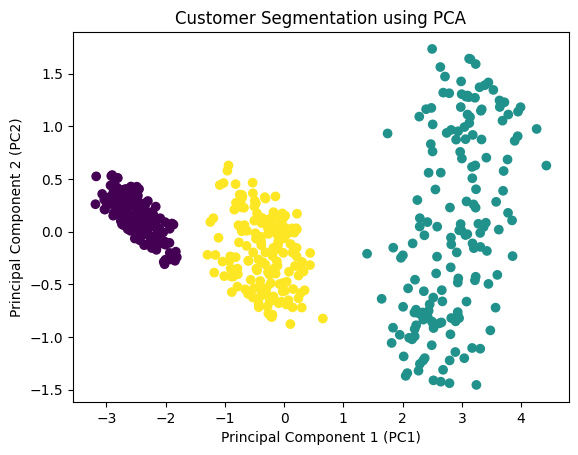

In [28]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['cluster']
)

plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("Customer Segmentation using PCA")

plt.show()